# DBSCAN on 4 Phone Classes: `aa`, `n`, `sh`, `sil`

Follow-up to `dbscan_5phone_classes_dim12.ipynb` and `dbscan_variants_5phone.ipynb`.

The previous run used the 5 densest non-silence classes `['s', 'ih', 'aa', 'iy', 'ae']`.
Even after tuning, DBSCAN collapsed `ih / iy / ae` into one mixed cluster and HDBSCAN only isolated `s`.

This notebook shrinks the problem again — 4 acoustically diverse classes chosen to be *separable* in MFCC space:

- `aa` — open back vowel (formant-structured, broad spectrum)
- `n`  — nasal (low-energy, damped spectrum, formant at low freq)
- `sh` — voiceless postalveolar fricative (high-frequency noise, c0 moderate)
- `sil` — silence (very low energy, near-zero c1..c11)

Rationale: vowel + nasal + fricative + silence should give four physically distinct density blobs in 12D MFCC space, which is the regime DBSCAN needs.

In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mplconfig")

import json
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.cluster import DBSCAN
from sklearn.manifold import TSNE
from sklearn.metrics import (
    adjusted_mutual_info_score,
    adjusted_rand_score,
    completeness_score,
    homogeneity_score,
    normalized_mutual_info_score,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

plt.style.use("ggplot")

with open("train_dim12.json", "r") as f:
    data = json.load(f)

RANDOM_SEED = 0
SELECTED_PHONEMES = ["aa", "n", "sh", "sil"]
FRAMES_PER_CLASS = 3_000        # stratified subset — sil would otherwise dominate
TSNE_SIZE = 4_000
TARGET_CLUSTERS = 4

print("num utterances:", len(data))
print("selected phonemes:", SELECTED_PHONEMES)
print("frames per class target:", FRAMES_PER_CLASS)

Matplotlib is building the font cache; this may take a moment.


num utterances: 4620
selected phonemes: ['aa', 'n', 'sh', 'sil']
frames per class target: 3000


## Frame-Level Expansion

Every utterance has `features` of shape `(T, 12)` and a `phn_transcript` of `(phone, start, end)` tuples in frame units. Expand this into a per-frame label array so each 12D frame carries a phoneme tag.

In [2]:
def expand_frame_labels(utt):
    T = len(utt["features"])
    frame_labels = np.full(T, "unlabeled", dtype=object)
    transcript = utt["phn_transcript"]
    for seg_idx, (label, start, end) in enumerate(transcript):
        start = max(0, min(int(start), T))
        end = max(start, min(int(end), T))
        if seg_idx == len(transcript) - 1 and end == T - 1:
            end = T
        if end > start:
            frame_labels[start:end] = label
    return frame_labels


frame_counter = Counter()
for utt in data.values():
    frame_counter.update(expand_frame_labels(utt).tolist())

counts_df = (
    pd.Series(frame_counter)
    .rename_axis("phone")
    .reset_index(name="frame_count")
    .sort_values("frame_count", ascending=False)
)
display(counts_df[counts_df["phone"].isin(SELECTED_PHONEMES)].reset_index(drop=True))

,phone,frame_count
0,sil,367150
1,aa,73885
2,n,46996
3,sh,27046


## Build The 4-Class Stratified Frame Dataset

`sil` has far more frames than `aa`/`n`/`sh`. We take an equal number of frames from each class so the density estimate is not biased toward silence. This is important for DBSCAN because a dominant class inflates global density and forces a single giant cluster.

In [3]:
def build_selected_frame_dataset(dataset, selected_phonemes):
    X_parts, y_parts, meta_parts = [], [], []
    selected_set = set(selected_phonemes)
    for utt_id, utt in dataset.items():
        feats = np.asarray(utt["features"], dtype=np.float32)
        frame_labels = expand_frame_labels(utt)
        mask = np.isin(frame_labels, list(selected_set))
        X_parts.append(feats[mask])
        y_parts.append(frame_labels[mask])
        meta_parts.append(pd.DataFrame({
            "utt_id": utt_id,
            "frame_idx": np.arange(len(frame_labels))[mask],
            "phoneme": frame_labels[mask],
        }))
    X = np.concatenate(X_parts, axis=0)
    y = np.concatenate(y_parts, axis=0)
    meta = pd.concat(meta_parts, ignore_index=True)
    return X, y, meta

X_full, y_full, meta_full = build_selected_frame_dataset(data, SELECTED_PHONEMES)
print("full 4-class matrix:", X_full.shape)
display(pd.Series(y_full).value_counts().rename_axis("phoneme").reset_index(name="frame_count"))

rng = np.random.default_rng(RANDOM_SEED)
idx_parts = []
for phone in SELECTED_PHONEMES:
    idx_phone = np.where(y_full == phone)[0]
    n_take = min(FRAMES_PER_CLASS, len(idx_phone))
    idx_parts.append(rng.choice(idx_phone, size=n_take, replace=False))
sub_idx = np.concatenate(idx_parts)
rng.shuffle(sub_idx)

X_sub = X_full[sub_idx]
y_sub = y_full[sub_idx]
meta_sub = meta_full.iloc[sub_idx].reset_index(drop=True)

scaler = StandardScaler()
X_sub_scaled = scaler.fit_transform(X_sub)

print("\nstratified subset:", X_sub.shape)
display(pd.Series(y_sub).value_counts().rename_axis("phoneme").reset_index(name="count"))

full 4-class matrix: (515077, 12)


,phoneme,frame_count
0,sil,367150
1,aa,73885
2,n,46996
3,sh,27046



stratified subset: (12000, 12)


,phoneme,count
0,n,3000
1,sil,3000
2,aa,3000
3,sh,3000


## Ground-Truth t-SNE Before Clustering

Embed the standardized 12D frames in 2D and color by true phone label. If this picture already shows mixed clouds for any pair, DBSCAN cannot recover those classes — the problem is the feature space, not the clustering algorithm.

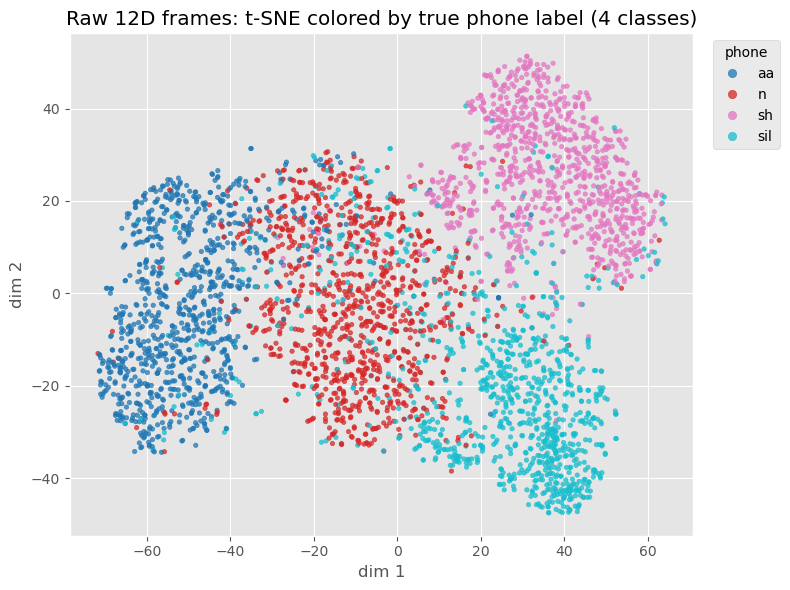

In [4]:
tsne_rng = np.random.default_rng(RANDOM_SEED)
vis_size = min(TSNE_SIZE, len(X_sub_scaled))
vis_idx = tsne_rng.choice(len(X_sub_scaled), size=vis_size, replace=False)
X_vis = X_sub_scaled[vis_idx]
y_vis = y_sub[vis_idx]

raw_embedding = TSNE(
    n_components=2, perplexity=30, init="pca",
    learning_rate="auto", random_state=RANDOM_SEED,
).fit_transform(X_vis)

label_codes = pd.Categorical(y_vis, categories=SELECTED_PHONEMES).codes
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(raw_embedding[:, 0], raw_embedding[:, 1],
                     c=label_codes, cmap="tab10", s=10, alpha=0.75)
ax.set_title("Raw 12D frames: t-SNE colored by true phone label (4 classes)")
ax.set_xlabel("dim 1"); ax.set_ylabel("dim 2")
handles, _ = scatter.legend_elements()
ax.legend(handles, SELECTED_PHONEMES, title="phone", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

## k-Distance Curve

For several candidate `min_samples`, plot the sorted distance to the k-th nearest neighbor. The elbow indicates the density transition between cluster interior and boundary — a good initial `eps` guess.

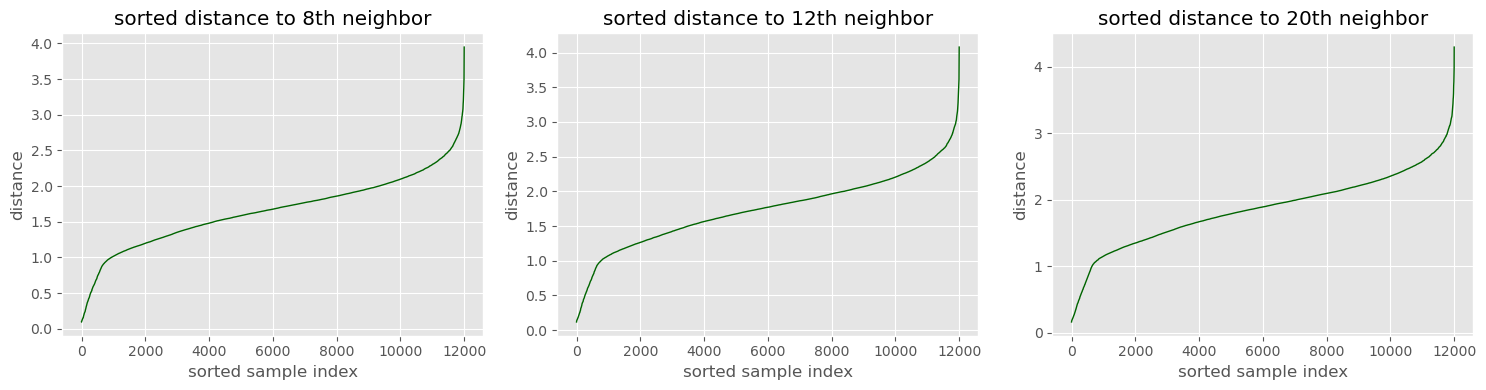

,k,q50,q75,q90,q95,q99
0,8,1.6765,1.9636,2.2508,2.4404,2.8311
1,12,1.7713,2.0680,2.3711,2.5688,2.9652
2,20,1.8898,2.2072,2.5202,2.7245,3.1419


In [5]:
k_values = [8, 12, 20]
rows = []
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, k in zip(axes, k_values):
    nbrs = NearestNeighbors(n_neighbors=k, algorithm="ball_tree").fit(X_sub_scaled)
    distances, _ = nbrs.kneighbors(X_sub_scaled)
    kth_dist = np.sort(distances[:, -1])
    ax.plot(kth_dist, color="darkgreen", linewidth=1)
    ax.set_title(f"sorted distance to {k}th neighbor")
    ax.set_xlabel("sorted sample index"); ax.set_ylabel("distance")
    q = np.quantile(kth_dist, [0.5, 0.75, 0.9, 0.95, 0.99])
    rows.append({"k": k, "q50": round(float(q[0]), 4), "q75": round(float(q[1]), 4),
                 "q90": round(float(q[2]), 4), "q95": round(float(q[3]), 4), "q99": round(float(q[4]), 4)})
plt.tight_layout(); plt.show()
display(pd.DataFrame(rows))

## DBSCAN Hyperparameter Sweep Toward 4 Clusters

Grid search `(eps, min_samples)` and rank by how close the cluster count comes to 4, then by clustering quality.

In [6]:
def dbscan_sweep(X, y, eps_grid, min_samples_grid, target_clusters=4):
    rows = []
    for min_samples in min_samples_grid:
        for eps in eps_grid:
            labels = DBSCAN(eps=eps, min_samples=min_samples,
                            algorithm="ball_tree", n_jobs=-1).fit_predict(X)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            clustered = labels >= 0
            rows.append({
                "min_samples": int(min_samples),
                "eps": float(eps),
                "clusters": int(n_clusters),
                "cluster_gap": int(abs(n_clusters - target_clusters)),
                "noise_fraction": round(float((labels == -1).mean()), 4),
                "coverage": round(float(clustered.mean()), 4),
                "ami": round(float(adjusted_mutual_info_score(y, labels)), 4),
                "nmi": round(float(normalized_mutual_info_score(y, labels)), 4),
                "ari": round(float(adjusted_rand_score(y, labels)), 4),
                "homogeneity": round(float(homogeneity_score(y, labels)), 4),
                "completeness": round(float(completeness_score(y, labels)), 4),
            })
    return pd.DataFrame(rows)

eps_grid = [round(v, 2) for v in np.arange(1.0, 2.1, 0.1)]
min_samples_grid = [6, 8, 10, 12, 15, 20]
sweep_df = dbscan_sweep(X_sub_scaled, y_sub, eps_grid, min_samples_grid,
                        target_clusters=TARGET_CLUSTERS)
ranked = sweep_df.sort_values(["cluster_gap", "nmi", "noise_fraction"],
                              ascending=[True, False, True]).reset_index(drop=True)
display(ranked.head(15))

,min_samples,eps,clusters,cluster_gap,noise_fraction,coverage,ami,nmi,ari,homogeneity,completeness
0,12,1.4,4,0,0.6432,0.3568,0.3084,0.3088,0.2293,0.2292,0.4730
1,10,1.4,4,0,0.6288,0.3712,0.3051,0.3055,0.2332,0.2283,0.4614
2,10,1.8,4,0,0.2177,0.7823,0.1048,0.1053,0.0535,0.0732,0.1876
3,8,1.9,4,0,0.1262,0.8738,0.0604,0.0610,0.0165,0.0391,0.1392
4,10,1.3,5,1,0.6983,0.3017,0.4217,0.4221,0.2213,0.3377,0.5625
5,12,1.3,3,1,0.7104,0.2896,0.4095,0.4097,0.2043,0.3234,0.5586
6,12,1.2,3,1,0.7653,0.2347,0.3405,0.3407,0.1255,0.2577,0.5027
7,20,1.6,5,1,0.5417,0.4583,0.3143,0.3147,0.2617,0.2402,0.4563
8,15,1.4,3,1,0.6592,0.3408,0.3099,0.3102,0.2211,0.2283,0.4838
9,12,1.5,3,1,0.5715,0.4285,0.3040,0.3042,0.2511,0.2285,0.4551


In [7]:
best_row = ranked.iloc[0]
selected_eps = float(best_row["eps"])
selected_min_samples = int(best_row["min_samples"])

cluster_labels = DBSCAN(eps=selected_eps, min_samples=selected_min_samples,
                        algorithm="ball_tree", n_jobs=-1).fit_predict(X_sub_scaled)
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)

print(f"selected eps        : {selected_eps}")
print(f"selected min_samples: {selected_min_samples}")
print(f"clusters found      : {n_clusters}")
print(f"noise fraction      : {(cluster_labels == -1).mean():.4f}")
print(f"coverage            : {(cluster_labels >= 0).mean():.4f}")
print(f"AMI : {adjusted_mutual_info_score(y_sub, cluster_labels):.4f}")
print(f"NMI : {normalized_mutual_info_score(y_sub, cluster_labels):.4f}")
print(f"ARI : {adjusted_rand_score(y_sub, cluster_labels):.4f}")

selected eps        : 1.4
selected min_samples: 12
clusters found      : 4
noise fraction      : 0.6432
coverage            : 0.3568
AMI : 0.3084
NMI : 0.3088
ARI : 0.2293


## Cluster Composition

Which phone dominates each DBSCAN cluster, and how pure is it?

In [8]:
cluster_df = meta_sub.copy()
cluster_df["cluster"] = cluster_labels
clustered_df = cluster_df[cluster_df["cluster"] >= 0]

if len(clustered_df) == 0:
    print("All points labelled as noise.")
else:
    rows = []
    for cid, group in clustered_df.groupby("cluster"):
        counts = group["phoneme"].value_counts()
        rows.append({
            "cluster": int(cid),
            "size": int(len(group)),
            "majority_phoneme": counts.index[0],
            "majority_fraction": round(float(counts.iloc[0] / len(group)), 4),
            "num_unique_phonemes": int(group["phoneme"].nunique()),
        })
    display(pd.DataFrame(rows).sort_values(["size", "majority_fraction"], ascending=[False, False]))

ct = pd.crosstab(pd.Series(y_sub, name="true"),
                 pd.Series(cluster_labels, name="cluster"))
display(ct)

,cluster,size,majority_phoneme,majority_fraction,num_unique_phonemes
0,0,4246,sh,0.5810,4
2,2,20,n,0.9500,2
3,3,10,n,1.0000,1
1,1,6,n,0.6667,2


cluster,-1,0,1,2,3
true,,,,,
aa,2997,3,0,0,0
n,2841,126,4,19,10
sh,533,2467,0,0,0
sil,1347,1650,2,1,0


## Ground Truth vs DBSCAN on The Same t-SNE

Two panels over the same 2D embedding: left colored by true phone, right by DBSCAN cluster id (`-1` = noise). Visually compare geometric structure vs discovered partition.

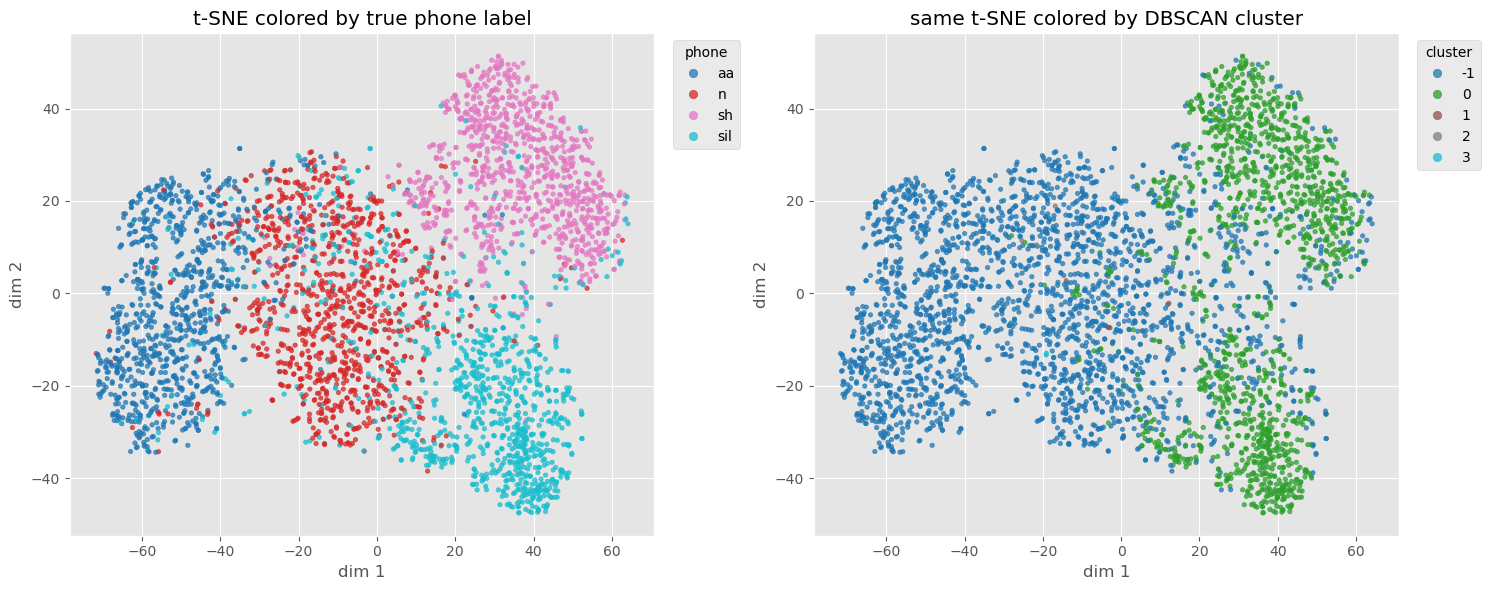

In [9]:
cluster_vis = cluster_labels[vis_idx]
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

scatter0 = axes[0].scatter(raw_embedding[:, 0], raw_embedding[:, 1],
                           c=label_codes, cmap="tab10", s=10, alpha=0.75)
axes[0].set_title("t-SNE colored by true phone label")
axes[0].set_xlabel("dim 1"); axes[0].set_ylabel("dim 2")
h0, _ = scatter0.legend_elements()
axes[0].legend(h0, SELECTED_PHONEMES, title="phone",
               bbox_to_anchor=(1.02, 1), loc="upper left")

scatter1 = axes[1].scatter(raw_embedding[:, 0], raw_embedding[:, 1],
                           c=cluster_vis, cmap="tab10", s=10, alpha=0.75)
axes[1].set_title("same t-SNE colored by DBSCAN cluster")
axes[1].set_xlabel("dim 1"); axes[1].set_ylabel("dim 2")
if np.any(cluster_vis >= 0):
    uniq = sorted(set(cluster_vis.tolist()))
    h1, _ = scatter1.legend_elements()
    axes[1].legend(h1[:len(uniq)], [str(c) for c in uniq], title="cluster",
                   bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

## Takeaway

Inspect, in order:

1. Ground-truth t-SNE — are `aa / n / sh / sil` already four visible islands?
2. DBSCAN on same embedding — does it recover those islands, or collapse vowel + nasal into one blob and drop the rest as noise?
3. Cluster composition table — which phones share a cluster.

If DBSCAN still collapses structure even at 4 well-separated classes, the next experiment (`dbscan_4phone_mcmc_gmm_dim12.ipynb`) fits a GMM per class and MCMC-samples only the high-density cores, stripping the overlapping tails. DBSCAN on that cleaner synthetic set is expected to cluster cleanly — the point is to isolate whether the bottleneck is the algorithm or the tail overlap.